In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# importando o dataframe 
# obs: o dataframe utilizado está disponível nesse link aqui: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud?resource=download
# não consegui colocar ele no github pois o dataframe ultrapassa 50mb
df = pd.read_csv('creditcard/creditcard.csv')
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [ ]:
# contando a quantidade de fraudes e não fraudes que tem
# 1 = fraude
# 0 = não fraude
count = df['Class'].value_counts(sort=True)
count

Class
0    284315
1       492
Name: count, dtype: int64

A escolha desse dataset para fazer a prática é porque ele conta com uma diferença grande entre os dois possiveis resultados, fraude e não fraude.

Ou seja, uma boa escolha para treinar como lidar com dados desbalanceados.

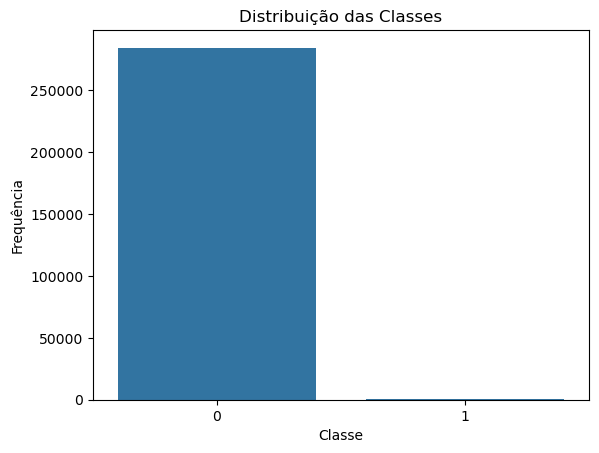

In [14]:
# Fazendo a contagem de quantas linhas cada classe contem no dataframe
sns.countplot(x='Class', data=df)
# colocando as informações de nome e das labels
plt.title('Distribuição das Classes')
plt.xlabel('Classe')
plt.ylabel('Frequência')
plt.show()

In [47]:

# Pegando apenas o dataframe, sem a informação se é fraude ou não
X = df.drop('Class', axis=1) 
X

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,scaled_amount,scaled_time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,1.783274,-0.994983
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.269825,-0.994983
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,4.983721,-0.994972
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,1.418291,-0.994972
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0.670579,-0.994960
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,-0.296653,1.034951
284803,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,0.038986,1.034963
284804,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,0.641096,1.034975
284805,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,-0.167680,1.034975


In [25]:
# importando as bibliotecas para fazer o treinamento
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

In [48]:
# pegando apenas as informações se é fraude ou não
y = df['Class']
y

0         0
1         0
2         0
3         0
4         0
         ..
284802    0
284803    0
284804    0
284805    0
284806    0
Name: Class, Length: 284807, dtype: int64

In [49]:
# definindo os valores x e y dos treinamentos e dos testes
# o parametro stratify serve pra manter a mesma proporção de fraudes e não fraudes no treino e no teste, por isso passamos o Y, que são os resultados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [50]:
# Treinando o modelo do KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [51]:
# fazendo as previsões
y_predict = knn.predict(X_test)

In [52]:
matrix = confusion_matrix(y_test, y_predict)


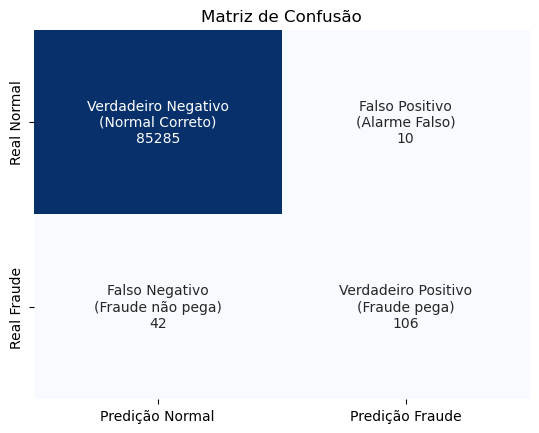

In [53]:
# separando os valores de falso positivo, falso negativo etc
tn, fp, fn, tp = matrix.ravel()

# Criando as labels para cada parte
labels = [f'Verdadeiro Negativo\n(Normal Correto)\n{tn}',
          f'Falso Positivo\n(Alarme Falso)\n{fp}',
          f'Falso Negativo\n(Fraude não pega)\n{fn}',
          f'Verdadeiro Positivo\n(Fraude pega)\n{tp}']

# Organizando os textos conforme a tabela
labels = np.asarray(labels).reshape(2,2)

# colocando o gráfico
sns.heatmap(matrix, annot=labels, fmt='', cmap='Blues', cbar=False,
            xticklabels=['Predição Normal', 'Predição Fraude'],
            yticklabels=['Real Normal', 'Real Fraude'])

plt.title('Matriz de Confusão')
plt.show()

Como esperado, o resultado da matriz de confusão mostra o problema ocorrido, de todas as 148 fraudes no dataset, apenas 3 fraudes foram pegas. Se formos analisar apenas a porcentagem de acertos do modelo, de fato a porcentagem será altíssima, porém não demonstra que o modelo é bom, pois as vezes em que a gente queria que ele pegasse, ele não pegou. O objetivo agora é corrigir isso.

In [33]:
# importando o smote, vamos utilizar a tecnica de criar clones sintéticos até que a quantidade de fraudes seja igual a de não fraudes
from imblearn.over_sampling import SMOTE

In [34]:
# criando o smote
smote = SMOTE(random_state=42)

In [54]:
# criando os novos dados sintéticos com os dados de treino
X_train_new, y_train_new = smote.fit_resample(X_train, y_train)

In [55]:
y_train_new.value_counts()
# como é possivel ver, a quantidade de dados agora é a mesma, tanto para fraude quanto para não fraudes

Class
0    199020
1    199020
Name: count, dtype: int64

In [56]:
# fazendo o treinamento mas agora com os dados criados pelo smote
knn_smote = KNeighborsClassifier(n_neighbors=5)
knn_smote.fit(X_train_new, y_train_new)

KNeighborsClassifier()

In [57]:
# fazendo previsões
y_smote_predict = knn_smote.predict(X_test)

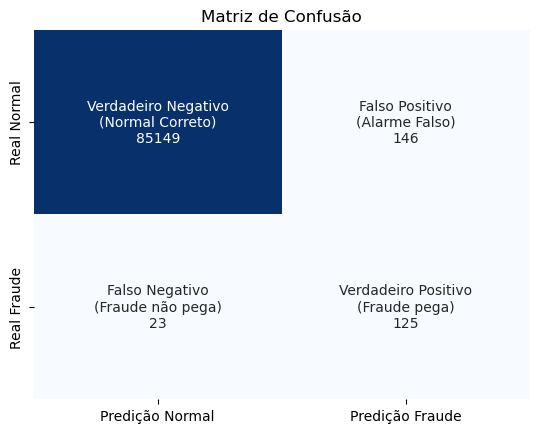

In [58]:
# criando a matriz
matrix = confusion_matrix(y_test, y_smote_predict)

# separando os valores de falso positivo, falso negativo etc
tn, fp, fn, tp = matrix.ravel()

# Criando as labels para cada parte
labels = [f'Verdadeiro Negativo\n(Normal Correto)\n{tn}',
          f'Falso Positivo\n(Alarme Falso)\n{fp}',
          f'Falso Negativo\n(Fraude não pega)\n{fn}',
          f'Verdadeiro Positivo\n(Fraude pega)\n{tp}']

# Organizando os textos conforme a tabela
labels = np.asarray(labels).reshape(2,2)

# colocando o gráfico
sns.heatmap(matrix, annot=labels, fmt='', cmap='Blues', cbar=False,
            xticklabels=['Predição Normal', 'Predição Fraude'],
            yticklabels=['Real Normal', 'Real Fraude'])

plt.title('Matriz de Confusão')
plt.show()

Conseguimos reduzir os falsos negativos e aumentar os verdadeiros positivos, o que é bom, porém ainda precisamos diminuir o falso positivo. É normal que ele aumente, mas não nessa quantidade absurda, portanto iremos tentar algumas soluções

In [46]:
# importando biblioteca
from sklearn.preprocessing import RobustScaler

# utilizando a biblioteca do robust scaler para normalizar as colunas de amount e time que podem conter valores muito grandes
rob_scaler = RobustScaler()

# criando as novas colunas ajustadas
df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))

# removendo as colunas originais para não dar conflito
df.drop(['Time', 'Amount'], axis=1, inplace=True)

Irei apenas rodar novamente os códigos de treinamento e ver o que da

Após rerodar os códigos, agora com os valores normalizados, o resultado ficou bem melhor